With this notebook, all used graphs can be reproduced. Data is read in from .npz files

In [1]:
import torch
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import PCGP.gpytorch_tools as gt
from mpl_toolkits.mplot3d import Axes3D  # Needed for 3D plotting
from matplotlib import cm  # Colormaps
from matplotlib import gridspec
import matplotlib.colors as mcolors
from matplotlib.patches import Patch

/home/johanna/VENTUS/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
plt.rcParams.update({'font.size': 22})
base_dir = os.getcwd()
save_dir = os.path.join(base_dir, "graphs")

data_dir_ex1 = os.path.join(base_dir, "Experiment1_Helmholtz", "output_data")
data_dir_ex2 = os.path.join(base_dir, "Experiment2_Bipendulum", "output_data")
data_dir_ex3 = os.path.join(base_dir, "Experiment3_LumpedHeat", "output_data")

# Forward Problem, Experiment 1 Helmholtz

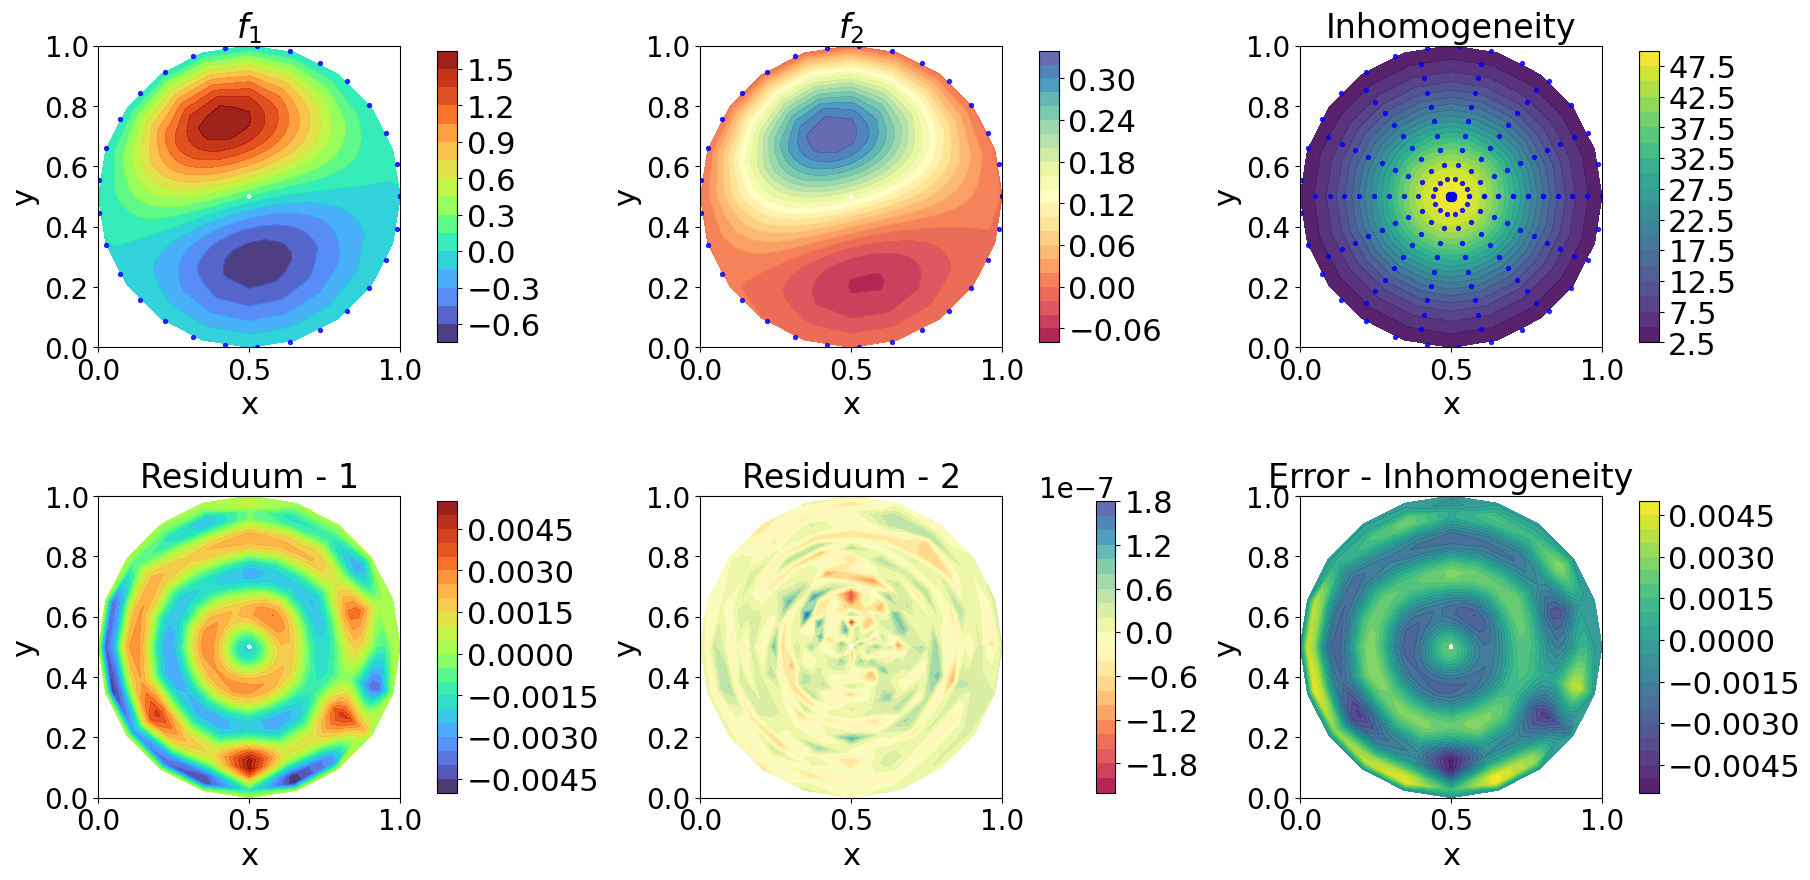

In [12]:
n_r, n_p, n_bc, ntest = 10, 15, 30, 21
data_path_ex1 = os.path.join(data_dir_ex1, "Ex1_nr%i_np%i_nbc%i_ntest%i.npz"%(n_r, n_p, n_bc, ntest))
data_ex1 = np.load(data_path_ex1)
for key in data_ex1:
    globals()[key] = torch.tensor(data_ex1[key])


fig, axes = plt.subplots(2, 3, figsize=(18, 9), constrained_layout=True)

# Titles, colormaps, and data to loop over
plots = [
    (test_y[0], r"$f_1$", "turbo", 0),
    (test_y[1], r"$f_2$", "Spectral", 1),
    (test_y[2], "Inhomogeneity", "viridis", 2),
    (error[0], "Residuum - 1", "turbo", 3),
    (error[1], "Residuum - 2", "Spectral", 4),
    (error[2], "Error - Inhomogeneity", "viridis", 5),
]

for ax, (Z, title, cmap, k) in zip(axes.flat, plots):
    # Filled contour
    surf = ax.contourf(test_x[0], test_x[1], Z, cmap=cmap, levels=20, alpha=0.9)
    #
    if k == 4:
        cbar = fig.colorbar(surf, ax=ax, shrink=0.7, aspect=15)
        cbar.formatter.set_powerlimits((0, 0))   # always use scientific notation in ticks
        #cbar.ax.yaxis.get_offset_text().set(size=20, va="bottom", ha="left")  # move/resize
        offset = cbar.ax.yaxis.get_offset_text()
        offset.set(size=20)#, va="bottom", ha="left")
        x, y = offset.get_position()
        # shift by 5% of the colorbar height
        offset.set_position((x, y + 0.1))
        cbar.update_ticks()
    else:
        fig.colorbar(surf, ax=ax, shrink=0.7, aspect=15)

    # Training points
    if k<3:
        mask = ~torch.isnan(train_y[:, k])  # keep only non-NaN rows
        ax.scatter(train_x[mask, 0], train_x[mask, 1],color="blue", s=8, alpha=0.8)
    #ax.scatter(train_x[:, 0], train_x[:, 1], color="blue", s=8, alpha=0.8)

    # Labels and title
    ax.set_title(title, fontsize=24)
    ax.set_xlabel("x", fontsize=22)
    ax.set_ylabel("y", fontsize=22)

    # Square axes
    ax.set_aspect("equal")

    # Ticks formatting (optional, cleaner numbers)
    ax.tick_params(axis="both", labelsize=20)

# Save high-res figure
plt.savefig(os.path.join(save_dir, "Ex1.png"), dpi=300, bbox_inches='tight')


# Experiment 2

/tmp/ipykernel_20199/1921707077.py:131: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  plt.savefig(os.path.join(save_dir, "Ex2.png"), dpi=300,bbox_inches='tight')
/home/johanna/VENTUS/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: There are no gridspecs with layoutgrids. Possibly did not call parent GridSpec with the "figure" keyword
  fig.canvas.print_figure(bytes_io, **kw)


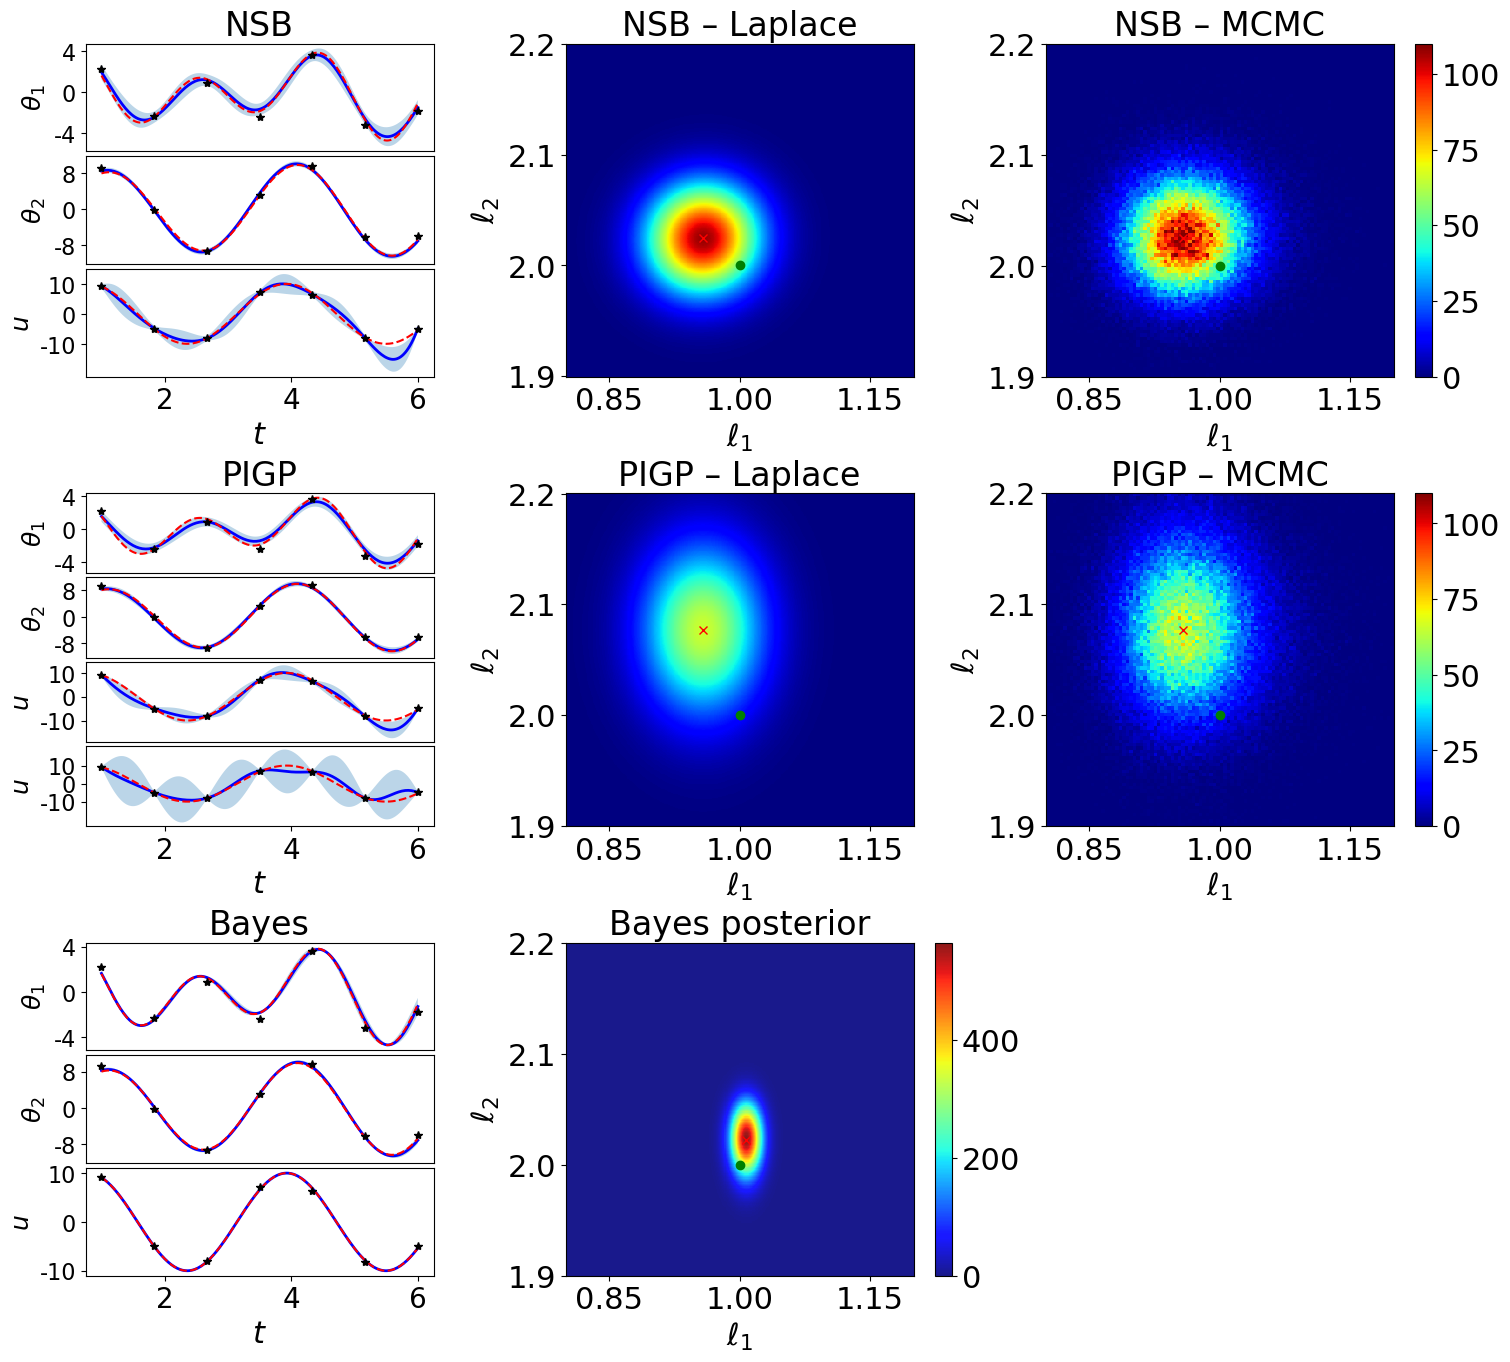

In [13]:
import matplotlib.pyplot as plt
from matplotlib import gridspec
import torch
import numpy as np

modes = ["NSB", "PIGP", "Bayes"]
titles = ["NSB", "PIGP", "Bayes"]
num_tasks_list = [3, 4, 3]  # given
npoints = 7
sigma = 0.5
end = 6
run = 0

cmap = "jet"
fig = plt.figure(figsize=(18, 16), constrained_layout=True)

task_labels = [r"$\theta_1$", r"$\theta_2$", r"$u$", r"$u$"]  # extend if needed
color_axes = []
# Outer GridSpec: 3 rows × 1 column, height proportional to num_tasks
outer = gridspec.GridSpec(3, 1,  hspace=0.35)

for row, (mode, title,  num_tasks) in enumerate(zip(modes, titles, num_tasks_list)):

    # ----------------- Load dataset -----------------
    if mode != "Bayes":
        data_ex2 = np.load(os.path.join(data_dir_ex2, "fixedAl",
                                        f"Ex2_{mode}_n{npoints}_sigma{sigma:.2f}_end{end}_{run}.npz"))
        for key in data_ex2:
            globals()[key] = torch.tensor(data_ex2[key])
    else:
        data_bayes = np.load(os.path.join(data_dir_ex2, "Bayes",
                                          f"Ex2_{mode}_n{npoints}_sigma{sigma:.2f}_end{end}.npz"))
        for key in data_bayes:
            globals()[key] = torch.tensor(data_bayes[key])

    # ----------------- Create nested GridSpec per row -----------------
    if row < 2:  # first two rows use normal ratios
        row_gs = gridspec.GridSpecFromSubplotSpec(1, 3, subplot_spec=outer[row], width_ratios=[4, 4, 5], wspace=0.35)
        
    else:        # last row: make middle column wider
        row_gs = gridspec.GridSpecFromSubplotSpec(1, 3, subplot_spec=outer[row], width_ratios=[4, 5, 4], wspace=0.35)

    # ----------------- LEFT BLOCK: stacked time series -----------------
    inner = gridspec.GridSpecFromSubplotSpec(num_tasks, 1, subplot_spec=row_gs[0], hspace=0.05)
    for i in range(num_tasks):
        ax = fig.add_subplot(inner[i, 0])
        ax.plot(test_x, mean[:, i], 'b', linewidth=2)
        ax.fill_between(test_x, lower[:, i], upper[:, i], alpha=0.3)
        ax.plot(test_x, test_y[:, i], "r--")
        mask = ~torch.isnan(train_y[:, i])
        ax.plot(train_x[mask], train_y[mask, i], 'k*')
        ax.set_ylabel(task_labels[i] if i < len(task_labels) else f"f_{i+1}", fontsize=22)
        if i < num_tasks - 1:
            ax.tick_params(labelbottom=False, bottom = False, labelsize=20)
        else:
            ax.set_xlabel(r"$t$", fontsize=22)
            ax.tick_params(labelsize=20)
        if i == 0:
            ax.set_title(title, fontsize=24)
       # ax.tick_params(labelsize=16)  # smaller font for stacked plots
        ax.set_ylabel(task_labels[i], fontsize=18)
        if i==1:
            y_ticks = [8, 0, -8]
        if i>=2:
            y_ticks = [10, 0, -10]
        if i == 0: 
            y_ticks = [4, 0, -4]
        ax.set_yticks(y_ticks)
        ax.set_yticklabels([f"{t:.0f}" for t in y_ticks], fontsize=16)
    # ----------------- MIDDLE BLOCK: Laplace / Bayes posterior -----------------
    ax_laplace = fig.add_subplot(row_gs[1])
    if mode != "Bayes":
        # Laplace plotting code
        N = 400
        xlim = (0.8, 1.2)
        ylim = (1.9, 2.2)
        mesh_1 = torch.linspace(xlim[0], xlim[1], N)
        mesh_2 = torch.linspace(ylim[0], ylim[1], N)
        param1, param2 = torch.meshgrid(mesh_1, mesh_2, indexing="xy")
        mu = learned_parameters[:2]
        inv_cov = torch.inverse(laplace_covariance[:2, :2])
        param_vec = torch.stack([param1.flatten(), param2.flatten()], dim=-1)
        exponent_raw = torch.einsum('bi,ij,bj->b', param_vec - mu, inv_cov, param_vec - mu)
        prob_density = torch.exp(-0.5 * (exponent_raw - exponent_raw.min()))
        prob_density /= prob_density.sum() * (mesh_1[1]-mesh_1[0])*(mesh_2[1]-mesh_2[0])
        prob_density = prob_density.reshape(N, N)

        surf = ax_laplace.pcolormesh(param1, param2, prob_density, cmap=cmap, shading="auto")
        ax_laplace.plot(true_parameters[0], true_parameters[1], "go")
        ax_laplace.plot(learned_parameters[0], learned_parameters[1], "rx")
        ax_laplace.set_title(f"{title} – Laplace", fontsize=24)
    else:
        mesh_2, mesh_1 = np.meshgrid(grid_l1, grid_l2)
        surf = ax_laplace.pcolormesh(mesh_1, mesh_2, posterior, cmap=cmap, shading='auto', alpha=0.9)
        ax_laplace.plot(true_parameters[0], true_parameters[1], "go")
        ax_laplace.plot(expected_parameters[0], expected_parameters[1], "rx")
        ax_laplace.set_xlim(0.8, 1.2)
        ax_laplace.set_ylim(1.9, 2.2)
        ax_laplace.set_title("Bayes posterior", fontsize=24)
        fig.colorbar(surf, ax=ax_laplace)

    ax_laplace.set_xlabel(r"$\ell_1$", fontsize=22)
    x_ticks = [0.85, 1.0, 1.15]
    ax_laplace.set_xticks(x_ticks)
    ax_laplace.set_xticklabels([f"{t:.2f}" for t in x_ticks], fontsize=22)
    ax_laplace.set_ylabel(r"$\ell_2$", fontsize=22)

    # ----------------- RIGHT BLOCK: MCMC / posterior -----------------
    ax_mcmc = fig.add_subplot(row_gs[2])
    if mode != "Bayes":
        counts, xedges, yedges, im = ax_mcmc.hist2d(samples_l1[:], samples_l2[:], bins=100,
                                                    cmap=cmap, density=True, range=[xlim, ylim])
        ax_mcmc.plot(true_parameters[0], true_parameters[1], "go")
        ax_mcmc.plot(learned_parameters[0], learned_parameters[1], "rx")
        fig.colorbar(surf, ax=ax_mcmc)
        ax_mcmc.set_title(f"{title} – MCMC", fontsize=24)
        x_ticks = [0.85, 1.0, 1.15]
        ax_mcmc.set_xticks(x_ticks)
        ax_mcmc.set_xticklabels([f"{t:.2f}" for t in x_ticks], fontsize=22)
        ax_mcmc.set_xlabel(r"$\ell_1$", fontsize=22)
        ax_mcmc.set_ylabel(r"$\ell_2$", fontsize=22)
    else:
        ax_mcmc.axis("off")  # optionally hide if not needed
    if row < 2:
        color_axes.extend([ax_laplace, ax_mcmc])
vmin = 0
vmax = 110
for ax in color_axes:
    for coll in ax.collections:
        coll.set_clim(vmin, vmax)
plt.savefig(os.path.join(save_dir, "Ex2.png"), dpi=300,bbox_inches='tight')
#plt.show()


## Metrics

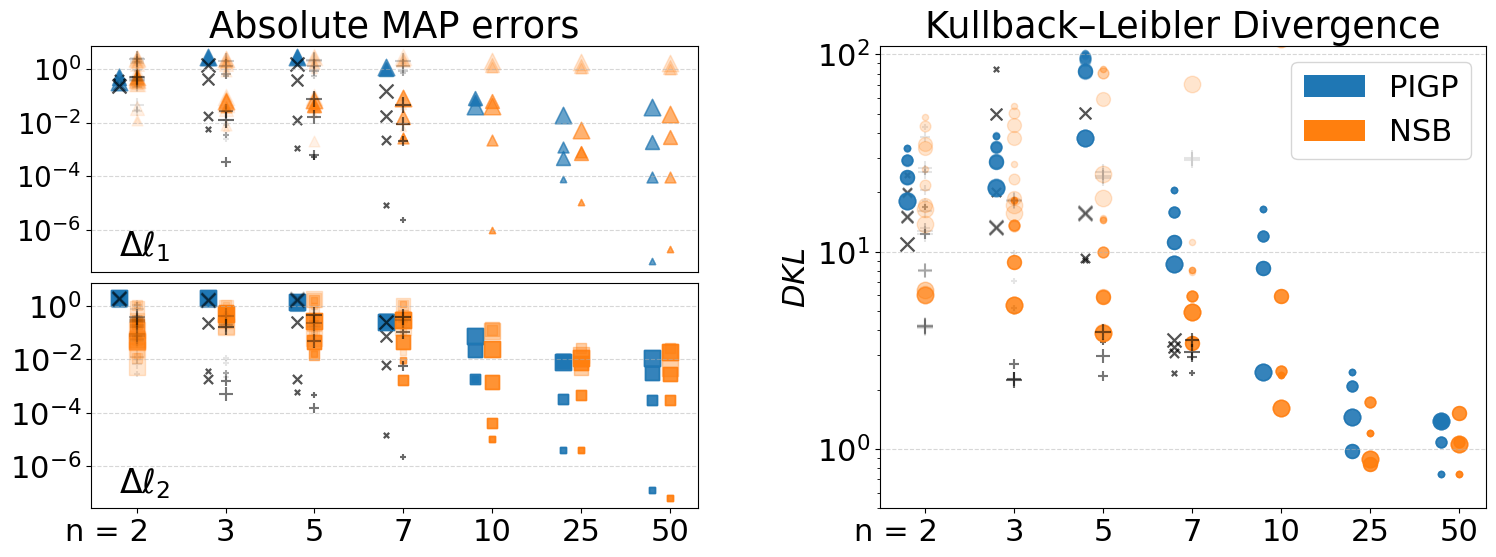

In [58]:
#get data
data_AE = np.load(os.path.join(data_dir_ex2, "Ex2_AE_with_n234.npz"))
data_DKL = np.load(os.path.join(data_dir_ex2, "Ex2_DKL_with_n234.npz"))
sigma_list = data_DKL["sigma_list"]
n_list = list(data_DKL["n_list"])
all_AE_end2 = data_AE["all_AE_end2"]
all_AE_end6 = data_AE["all_AE_end6"]
all_DKL_end2 = data_DKL["all_DKL_end2"]#np.where(data_DKL["all_DKL_end2"]<=2e1, data_DKL["all_DKL_end2"], 1e2) #Ausreißer weggeben
all_DKL_end6 = data_DKL["all_DKL_end6"]#np.where(data_DKL["all_DKL_end6"]<=5e1, data_DKL["all_DKL_end6"], 1e2) #Ausreißer weggeben
n_list.remove(4)
#for plotting
width = 0.05
group_spacing = 0.3
num_boxes_per_group = 4
scale_factor = 40
base_size = 20
symbol = ["^", "^", "s", "s"]
markers = ["x", "+", 1/np.sqrt(2), 1]
colors = list(mcolors.TABLEAU_COLORS.values())

fig = plt.figure(figsize=(18, 6))
gs = gridspec.GridSpec(1, 2, width_ratios=[2, 2], wspace=0.3)

# --- LEFT AXIS: split into 2 rows ---
gs_left = gridspec.GridSpecFromSubplotSpec(2, 1, subplot_spec=gs[0, 0], hspace=0.05)
ax00 = fig.add_subplot(gs_left[0, 0])  # top subplot
ax01 = fig.add_subplot(gs_left[1, 0], sharey=ax00)  # bottom subplot

# --- RIGHT AXIS ---
ax1 = fig.add_subplot(gs[0, 1])

j_list = [0, 1, 2, 3]

# --- LEFT TOP: j=0,1 ---
for n_idx, n in enumerate(n_list):
    group_pos = n_idx * (num_boxes_per_group * width + group_spacing)
    for j in range(2):  # j=0,1
        pos = group_pos + 2 * j * width
        for sigma_idx, sigma in enumerate(sigma_list):
            data = all_AE_end6[n_idx, sigma_idx, j]
            x_vals = np.full(len(data), pos)
            marker_size = base_size + scale_factor * sigma_idx
            ax00.scatter(x_vals, data,
                         marker=symbol[j], color=colors[j % len(colors)],
                         alpha=0.1, s=marker_size,
                         label=f'σ={sigma:.2f}' if n_idx == 0 and j == 0 else None)
            if n in [2,3,4,5, 7]:
                extra_y = np.atleast_1d(all_AE_end2[n_idx, sigma_idx, j])
                ax00.scatter(np.full(len(extra_y), pos), extra_y,
                            marker=markers[j], color="black", alpha=0.1,#colors[j % len(colors)]
                            s=marker_size*markers[j+2])
                ax00.tick_params(labelbottom=False, bottom = False, labelsize=20)
ax00.text(0, 1e-7, r"""$\Delta \ell_1$""", fontsize=24)
# --- LEFT BOTTOM: j=2,3 ---
for n_idx, n in enumerate(n_list):
    group_pos = n_idx * (num_boxes_per_group * width + group_spacing)
    for j in range(2, 4):  # j=2,3
        pos = group_pos + 2 * (j-2) * width  # reset spacing for bottom row
        for sigma_idx, sigma in enumerate(sigma_list):
            data = all_AE_end6[n_idx, sigma_idx, j]
            x_vals = np.full(len(data), pos)
            marker_size = base_size + scale_factor * sigma_idx
            ax01.scatter(x_vals, data,
                         marker=symbol[j], color=colors[(j-2) % len(colors)],
                         alpha=0.2, s=marker_size,
                         label=f'σ={sigma:.2f}' if n_idx == 0 and j == 2 else None)
            if n in [2,3,4,5, 7]:
                extra_y = np.atleast_1d(all_AE_end2[n_idx, sigma_idx, j])
                ax01.scatter(np.full(len(extra_y), pos), extra_y,
                            marker=markers[j-2], color = "black" , alpha=0.1,#color=colors[(j-2) % len(colors)]
                            s=marker_size*markers[j])
ax01.text(0, 1e-7, r"""$\Delta \ell_2$""", fontsize=24)
# --- format LEFT subplots ---
for ax in [ax00, ax01]:
    AE_xtick_positions = [i * (num_boxes_per_group * width + group_spacing)
                          + width*num_boxes_per_group/2 for i in range(len(n_list))]
    AE_xtick_labels = ["n = 2      " if n == 2 else f"{n}" for n in n_list]
    ax.set_xticks(AE_xtick_positions, AE_xtick_labels)
    ax.set_yscale("log")
    ax.grid(True, axis='y', linestyle='--', alpha=0.5)
ax00.set_title("Absolute MAP errors")
#ax01.set_title("Absolute MAP errors (j=2,3)")
#ax01.set_ylabel("Absolute Error")

# --- RIGHT AXIS (DKL, unchanged) ---
num_boxes_per_group_DKL = 2
for n_idx, n in enumerate(n_list):
    group_pos = n_idx * (num_boxes_per_group * width + group_spacing)#group_pos = n_idx * (num_boxes_per_group_DKL * width + group_spacing)
    for j in range(num_boxes_per_group_DKL):
        pos = group_pos + 2 * j * width
        for sigma_idx, sigma in enumerate(sigma_list):
            data = all_DKL_end6[n_idx, sigma_idx, j]
            x_vals = np.full(len(data), pos)
            marker_size = base_size + scale_factor * sigma_idx
            ax1.scatter(x_vals, data,
                        marker="o", color=colors[j % len(colors)],
                        alpha=0.2, s=marker_size,
                        label=f'σ={sigma:.2f}' if n_idx == 0 and j == 0 else None)

            if n in [2,3,4,5, 7]:
                extra_y = np.atleast_1d(all_DKL_end2[n_idx, sigma_idx, j])
                ax1.scatter(np.full(len(extra_y), pos), extra_y,
                            marker=markers[j], color="black", alpha=0.1,#colors[j % len(colors)]
                            s=marker_size*markers[j+2])
ax1.legend(handles = [Patch(facecolor=colors[0], label = "PIGP"), Patch(facecolor=colors[1], label = "NSB") ])
DKL_xtick_positions = [i * (num_boxes_per_group * width + group_spacing)
                       + width*num_boxes_per_group/2 for i in range(len(n_list))]
DKL_xtick_labels = ["n = 2      " if n == 2 else f"{n}" for n in n_list]
ax1.set_xticks(DKL_xtick_positions, DKL_xtick_labels)
ax1.set_ylabel(r"""$DKL$""")
ax1.set_title("Kullback–Leibler Divergence")
ax1.set_yscale("log")
ax1.set_ylim([5e-1, 1.1e2])
ax1.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.savefig(os.path.join(save_dir, "Ex2_metrics_with234.png"), dpi=300,bbox_inches='tight' )

# Experiment 3 Parameter tracking

## With Laplace priors

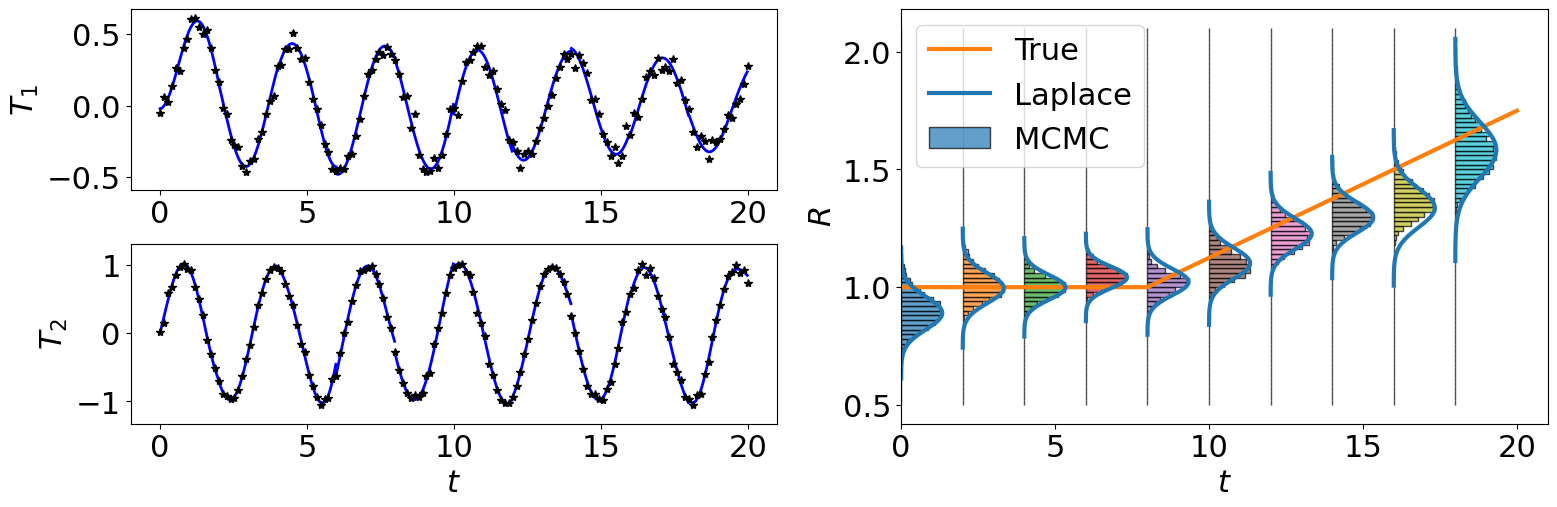

In [10]:
#load data
data_ex3 = np.load(os.path.join(data_dir_ex3, "Ex3_yes_priors.npz"))
for key in data_ex3:
    globals()[key] = torch.tensor(data_ex3[key])
number_of_models = mean.shape[0]
num_tasks = mean.shape[2]

# Posterior distribution setup
number_of_models = len(laplace_mean)
window_length = float((test_x[-1] - test_x[0]) / number_of_models)
bin_width = 0.02
bin_edges = np.arange(0.5, 2.1 + bin_width, bin_width)
number_of_bins = len(bin_edges) - 1
distributions = np.zeros((number_of_models, number_of_bins))
ranges = np.zeros((number_of_models, number_of_bins))
for i in range(number_of_models):
    hist, _ = np.histogram(samples[i], bins=bin_edges)
    distributions[i] = hist
    ranges[i] = 0.5 * (bin_edges[1:] + bin_edges[:-1])
t_positions = np.arange(number_of_models) * window_length

# Plotting
fig = plt.figure(figsize=(16, 5.5))
gs = gridspec.GridSpec(num_tasks, 2, width_ratios=[5, 5])

# Left: model predictions
for i in range(num_tasks):
    ax = fig.add_subplot(gs[i, 0])
    for j in range(number_of_models):
        ax.plot(test_x[120*j:120*(j+1)], mean[j, :, i], 'b', linewidth=2)
        ax.fill_between(test_x[j], lower[j, :, i], upper[j, :, i], alpha=0.5)
    ax.plot(train_x, train_y[:, i], 'k*')
    ax.set_ylabel(r"""$T_%i$"""%(i+1))
    if i == num_tasks - 1:
        ax.set_xlabel(r"""$t$""")


# Right: parameter evolution
ax = fig.add_subplot(gs[:, 1])
ax.plot(test_x, R_true, '-', label="True", color="C1", linewidth=3)
for i in range(number_of_models):
    hist = distributions[i]
    hist = hist / max(hist) / 1.5 * window_length
    y = ranges[i]
    x = np.full_like(y, t_positions[i])
    ax.barh(y, hist, height=y[1] - y[0], left=x, alpha=0.7, edgecolor='black', label="MCMC" if i == 0 else "")
for i in range(number_of_models):
    mu = laplace_mean[i]
    sigma = laplace_uncertainty[i]
    y = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 100)
    pdf = norm.pdf(y, mu, sigma)
    pdf = pdf / np.max(pdf) * window_length / 1.5
    x = np.full_like(y, t_positions[i])
    ax.plot(x + pdf, y, color="tab:blue", label="Laplace" if i == 0 else "", linewidth=3)
ax.set_xlabel(r"""$t$""")
ax.set_ylabel(r"""$R$""")
ax.legend()
plt.tight_layout(pad = 1.02, h_pad = 0.5)

plt.savefig(os.path.join(save_dir, "Ex3.png"), dpi=300)

## With flat priors

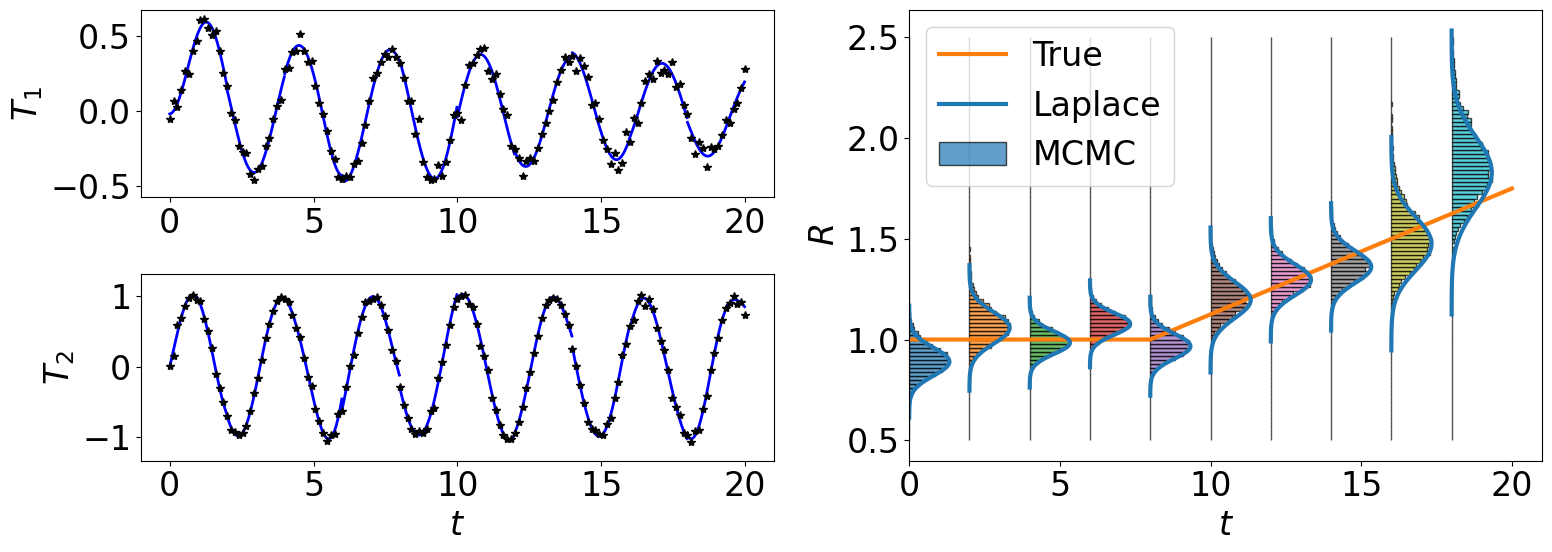

In [12]:
#load data
data_ex3 = np.load(os.path.join(data_dir_ex3, "Ex3_no_priors.npz"))
for key in data_ex3:
    globals()[key] = torch.tensor(data_ex3[key])
number_of_models = mean.shape[0]
num_tasks = mean.shape[2]

# Posterior distribution setup
number_of_models = len(laplace_mean)
window_length = float((test_x[-1] - test_x[0]) / number_of_models)
bin_width = 0.02
bin_edges = np.arange(0.5, 2.5 + bin_width, bin_width)
number_of_bins = len(bin_edges) - 1
distributions = np.zeros((number_of_models, number_of_bins))
ranges = np.zeros((number_of_models, number_of_bins))
for i in range(number_of_models):
    hist, _ = np.histogram(samples[i], bins=bin_edges)
    distributions[i] = hist
    ranges[i] = 0.5 * (bin_edges[1:] + bin_edges[:-1])
t_positions = np.arange(number_of_models) * window_length

# Plotting 
fig = plt.figure(figsize=(16, 6))
gs = gridspec.GridSpec(num_tasks, 2, width_ratios=[5, 5])

# Left: model predictions
for i in range(num_tasks):
    ax = fig.add_subplot(gs[i, 0])
    for j in range(number_of_models):
        ax.plot(test_x[120*j:120*(j+1)], mean[j, :, i], 'b', linewidth=2)
        ax.fill_between(test_x[j], lower[j, :, i], upper[j, :, i], alpha=0.5)
    ax.plot(train_x, train_y[:, i], 'k*')
    ax.set_ylabel(r"""$T_%i$"""%(i+1))
    if i == num_tasks - 1:
        ax.set_xlabel(r"""$t$""")
  

# Right: parameter evolution
ax = fig.add_subplot(gs[:, 1])
ax.plot(test_x, R_true, '-', label="True", color="C1", linewidth=3)
for i in range(number_of_models):
    hist = distributions[i]
    hist = hist / max(hist) / 1.5 * window_length
    y = ranges[i]
    x = np.full_like(y, t_positions[i])
    ax.barh(y, hist, height=y[1] - y[0], left=x, alpha=0.7, edgecolor='black', label="MCMC" if i == 0 else "")
for i in range(number_of_models):
    mu = laplace_mean[i]
    sigma = laplace_uncertainty[i]
    y = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 100)
    pdf = norm.pdf(y, mu, sigma)
    pdf = pdf / np.max(pdf) * window_length / 1.5
    x = np.full_like(y, t_positions[i])
    ax.plot(x + pdf, y, color="tab:blue", label="Laplace" if i == 0 else "", linewidth=3)
ax.set_xlabel(r"""$t$""")
ax.set_ylabel(r"""$R$""")
ax.legend()
plt.tight_layout(pad = 1.02)

plt.savefig(os.path.join(save_dir, "Ex3_no_priors.png"), dpi=300)